In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [8]:
df = pd.read_csv("/content/sample_data/HR_comma_sep.csv")
print(df.head())
print(df.info())

   satisfaction_level  last_evaluation  number_project  average_montly_hours  \
0                0.38             0.53               2                   157   
1                0.80             0.86               5                   262   
2                0.11             0.88               7                   272   
3                0.72             0.87               5                   223   
4                0.37             0.52               2                   159   

   time_spend_company  Work_accident  left  promotion_last_5years Department  \
0                   3              0     1                      0      sales   
1                   6              0     1                      0      sales   
2                   4              0     1                      0      sales   
3                   5              0     1                      0      sales   
4                   3              0     1                      0      sales   

   salary  
0     low  
1  medium  
2 

In [12]:
print(df.groupby('left').mean(numeric_only=True))

      satisfaction_level  last_evaluation  number_project  \
left                                                        
0               0.666810         0.715473        3.786664   
1               0.440098         0.718113        3.855503   

      average_montly_hours  time_spend_company  Work_accident  \
left                                                            
0               199.060203            3.380032       0.175009   
1               207.419210            3.876505       0.047326   

      promotion_last_5years  
left                         
0                  0.026251  
1                  0.005321  


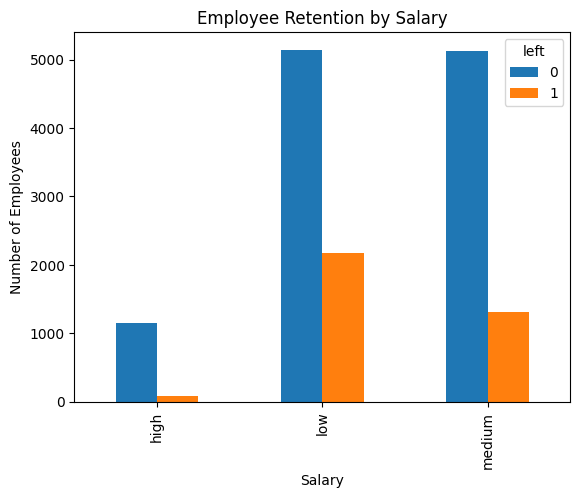

In [13]:
salary_retention = pd.crosstab(df.salary, df.left)

salary_retention.plot(kind='bar')
plt.title("Employee Retention by Salary")
plt.xlabel("Salary")
plt.ylabel("Number of Employees")
plt.show()

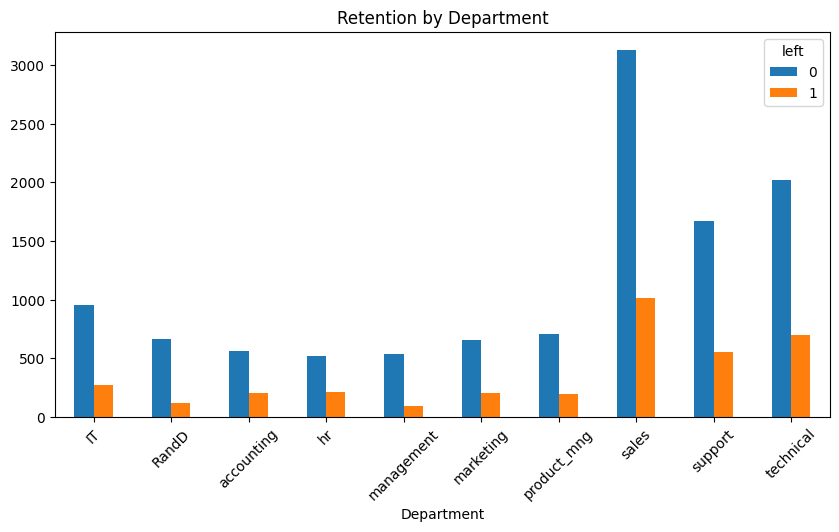

In [14]:
dept_retention = pd.crosstab(df.Department, df.left)

dept_retention.plot(kind='bar', figsize=(10,5))
plt.xticks(rotation=45)
plt.title("Retention by Department")
plt.show()

In [15]:
data = df[['satisfaction_level',
           'average_montly_hours',
           'promotion_last_5years',
           'salary']]

In [16]:
data = pd.get_dummies(data, columns=['salary'], drop_first=True)

In [17]:
X = data.values.astype(float)
y = df['left'].values

In [28]:
# Shuffle data
indices = np.arange(X.shape[0])
np.random.shuffle(indices)

X = X[indices]
y = y[indices]

# 80% train, 20% test
split = int(0.8 * len(X))

X_train = X[:split]
X_test = X[split:]
y_train = y[:split]
y_test = y[split:]

In [29]:
# Add column of 1s for bias
X_train = np.c_[np.ones(X_train.shape[0]), X_train]
X_test = np.c_[np.ones(X_test.shape[0]), X_test]

In [20]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [21]:
weights = np.zeros(X_train.shape[1])
learning_rate = 0.01
epochs = 1000

In [30]:
for i in range(epochs):

    z = np.dot(X_train, weights)
    predictions = sigmoid(z)

    # Gradient calculation
    gradient = np.dot(X_train.T, (predictions - y_train)) / len(y_train)

    # Update weights
    weights -= learning_rate * gradient

The code in the cell below ensures that the `X` array, and subsequently `X_train` and `X_test`, are composed of float values, resolving the `TypeError`.

In [24]:
X = data.values.astype(float)
y = df['left'].values

In [33]:
z_test = np.dot(X_test, weights)
predictions_test = sigmoid(z_test)

# Convert probabilities to 0 or 1
y_pred = [1 if p >= 0.5 else 0 for p in predictions_test]

In [34]:
correct = 0
for i in range(len(y_test)):
    if y_test[i] == y_pred[i]:
        correct += 1

accuracy = correct / len(y_test)
print("Accuracy:", accuracy)

Accuracy: 0.7736666666666666
